$$
\mathcal X = \mathcal X[:,:,0:T-1],
\qquad
\mathcal Y = \mathcal X[:,:,1:T]
$$

$$
\mathcal X = \mathcal U \star_M \mathcal S \star_M \mathcal V^*
$$

$$
\mathcal K = \mathcal U^* \star_M \mathcal Y \star_M \mathcal V \star_M \mathcal S^{\dagger}
$$

$$
\mathcal K = \mathcal W \star_M \mathcal T \star_M \mathcal W^*
$$

$$
\mathcal Z = \mathcal U \star_M \mathcal W
$$

$$
\widehat{\mathcal B}^{(\ell)} = \bigl(\widehat{\mathcal Z}^{(\ell)}\bigr)^{\dagger} \widehat{\mathcal X}_0^{(\ell)}
$$

$$
\widehat{\mathcal X}_{k}^{(\ell)} = \widehat{\mathcal Z}^{(\ell)} \bigl(\widehat{\mathcal T}^{(\ell)}\bigr)^k \widehat{\mathcal B}^{(\ell)}
$$

In [1]:
from pathlib import Path
from time import perf_counter
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from rich.console import Console
from rich.table import Table

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tdmd import FFTTransform, tdmd

plt.style.use("ggplot")

In [2]:
def make_plasma(nx=100, ny=100, nt=100):
    x = jnp.linspace(-1.0, 1.0, nx)
    y = jnp.linspace(-1.0, 1.0, ny)
    t = jnp.linspace(0.0, 4.0 * jnp.pi, nt)
    X, Y, T = jnp.meshgrid(x, y, t, indexing="ij")

    Xf = 5.0 * X - 5.0
    Yf = 5.0 * Y - 5.0
    R = jnp.sqrt(Xf**2 + Yf**2)
    Theta = jnp.arctan2(Yf, Xf + 1.0e-6)

    Z = (
        7.0 * jnp.sin(1.7 * Xf + 0.9 * T)
        + 6.0 * jnp.cos(1.3 * Yf - 1.2 * T)
        + 5.0 * jnp.sin(0.9 * (Xf + Yf) + 0.7 * T)
        + 4.0 * jnp.cos(2.2 * R - 1.8 * T)
        + 3.0 * jnp.sin(3.0 * Theta + 0.6 * R - 1.1 * T)
        + 2.5 * jnp.cos(1.8 * (Xf - Yf) + 0.3 * R + 0.8 * T)
    )
    return Z, t


def split_shifted_tensor(sequence):
    return sequence[:, :, :-1], sequence[:, :, 1:]


def embed_training_tensors(sequence, embed_len):
    x_train, y_train = split_shifted_tensor(sequence)
    X = jnp.zeros((sequence.shape[0], sequence.shape[1], embed_len), dtype=sequence.dtype)
    Y = jnp.zeros((sequence.shape[0], sequence.shape[1], embed_len), dtype=sequence.dtype)
    X = X.at[:, :, : x_train.shape[2]].set(x_train)
    Y = Y.at[:, :, : y_train.shape[2]].set(y_train)
    return X, Y


def relative_error(target, approx):
    return float(jnp.linalg.norm(target - approx) / jnp.linalg.norm(target))


def draw_frame(ax, frame, title, cmap="magma"):
    image = ax.imshow(np.asarray(jnp.real(frame)), origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return image


def predict_tdmd_state(first_snapshot, modes, schur_tensor, transform, pred_idx, embed_len):
    modes_hat = transform.to_slices(modes)
    schur_hat = transform.to_slices(schur_tensor)

    x0 = jnp.zeros((first_snapshot.shape[0], first_snapshot.shape[1], embed_len), dtype=first_snapshot.dtype)
    x0 = x0.at[:, :, 0].set(first_snapshot)
    x0_hat = transform.to_slices(x0)

    coeff_hat = jax.vmap(lambda phi, x: jnp.linalg.lstsq(phi, x, rcond=None)[0])(modes_hat, x0_hat)
    schur_hat_power = jax.vmap(lambda T: jnp.linalg.matrix_power(T, pred_idx))(schur_hat)

    y_hat_hat = modes_hat @ schur_hat_power @ coeff_hat
    y_hat_tensor = transform.from_slices(y_hat_hat)
    return jnp.real(y_hat_tensor[:, :, pred_idx])

In [6]:
Z, t = make_plasma(nx=96, ny=96, nt=128)
train_sequence = Z[:, :, :96]
embed_len = Z.shape[2]
X, Y = embed_training_tensors(train_sequence, embed_len)
L = FFTTransform()

rank = 20
energy_threshold = 0.995
svd_threshold = 1.0e-8

pred_idx = 127

start = perf_counter()
modes, schur_tensor = tdmd(
    X,
    Y,
    L,
    rank=rank,
    energy_threshold=energy_threshold,
    svd_threshold=svd_threshold,
)
y_hat = predict_tdmd_state(Z[:, :, 0], modes, schur_tensor, L, pred_idx, embed_len)
jax.block_until_ready(y_hat)
elapsed = perf_counter() - start

y_true = Z[:, :, pred_idx]
error = relative_error(y_true, y_hat)

table = Table(title="TDMD Results")

table.add_column("Name", no_wrap=True)
table.add_column("Value")

table.add_row("sequence shape", f"{tuple(Z.shape)}")
table.add_row("modes shape", f"{tuple(modes.shape)}")
table.add_row("schur tensor shape", f"{tuple(schur_tensor.shape)}")
table.add_row("relative error", f"{error:.4e}")

console = Console()
console.print(table)

             TDMD Results             
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Name               ┃ Value         ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence shape     │ (96, 96, 128) │
│ modes shape        │ (96, 5, 128)  │
│ schur tensor shape │ (5, 5, 128)   │
│ relative error     │ 4.3985e+00    │
└────────────────────┴───────────────┘

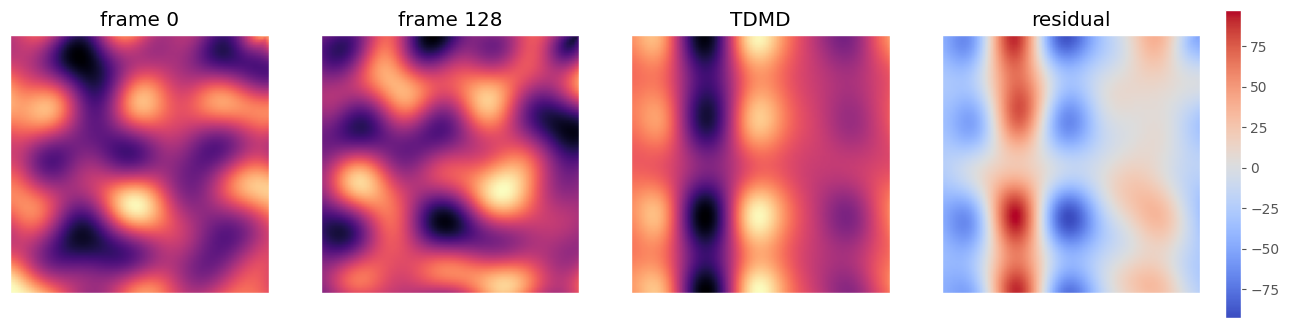

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img0 = draw_frame(axes[0], Z[:, :, 0], "frame 0")
img1 = draw_frame(axes[1], y_true, f"frame {pred_idx + 1}")
img2 = draw_frame(axes[2], y_hat, "TDMD")
img3 = draw_frame(axes[3], y_true - y_hat, "residual", cmap="coolwarm")
fig.colorbar(img3, ax=axes, fraction=0.02, pad=0.02)

plt.show();